# A2-01 · Object Detection — YOLOv4 from the Darknet config

We parse the **YOLOv4** Darknet configuration into PyTorch (the same way the lab parsed YOLOv3), load the official `yolov4.weights`, run 608×608 **RGB** inference, then train YOLOv4 on COCO and compare **MSE/IoU vs CIoU** box-regression losses.

**What was added on top of the YOLOv3 parser** (`detection/darknet.py`, `detection/util.py`):
* **Mish** activation (`x·tanh(softplus(x))`) across CSPDarknet53
* **`[maxpool]`** layers for the SPP block (sizes 5/9/13, stride 1)
* **`[route]` concatenating >2 layers** (SPP fuses four maps) and CSP **`groups`** splits
* **`scale_x_y`** grid-sensitivity decoding and **partial weight loading** for the ImageNet backbone `yolov4.conv.137`

In [1]:
import os, sys, json
# Run from the repository root so all paths match run.py / script.* .
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
import torch, numpy as np, pandas as pd
from IPython.display import Image, display

def show(path, width=None):
    if os.path.exists(path):
        display(Image(path, width=width))
    else:
        print(f'[figure not generated yet: {path}] — run: python make_figures.py')

def load_history(tag):
    p = f'checkpoints/history_{tag}.json'
    return json.load(open(p)) if os.path.exists(p) else None

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')


device: cuda | NVIDIA GeForce RTX 5060 Ti


## 1. The detection lineage: R-CNN → Faster R-CNN → YOLO

| Model | Proposals | Stages | Speed | Idea |
|---|---|---|---|---|
| R-CNN (2014) | Selective Search + 2000× CNN | 3 separate | ~47 s/img | CNN features per region |
| Fast R-CNN (2015) | Selective Search + 1× CNN | 1 joint | ~2 s/img | shared map + RoI pool |
| Faster R-CNN (2016) | RPN on GPU | 2 joint | ~0.2 s/img | learned proposals |
| **YOLOv3/v4** | **none** | **1 (single-shot)** | **real-time** | **dense grid prediction** |

### Why is YOLOv3 faster than Faster R-CNN?

**Faster R-CNN is two-stage.** A Region Proposal Network first scans the backbone feature map and emits ~1–2k candidate regions; a second detection head then crops each proposal (RoI-Align) and classifies/regresses it *individually*. That per-region second stage runs hundreds of times per image, doesn't batch cleanly, and sits — together with proposal generation and its NMS — on the critical path.

**YOLOv3 is single-shot.** One fully-convolutional forward pass densely predicts, at every cell of three feature-map scales (strides 8/16/32), the box offsets, objectness and class scores for a fixed set of anchors. There is **no proposal stage and no per-RoI head** — detection is one batched CNN pass plus a single cheap NMS. Hence ~30–60 FPS for YOLOv3 vs ~5–7 FPS for Faster R-CNN at comparable accuracy. The historical cost was weaker localisation on small/overlapping objects, which multi-scale anchors and CIoU loss (YOLOv4) largely recover.

## 2. YOLOv4 architecture

**CSPDarknet53 backbone** (Mish, cross-stage-partial blocks) → **neck** = SPP (maxpool 5/9/13) + **PANet** (top-down + bottom-up feature fusion) → **3 YOLO heads** (strides 8/16/32). The architecture diagram from the course notes:

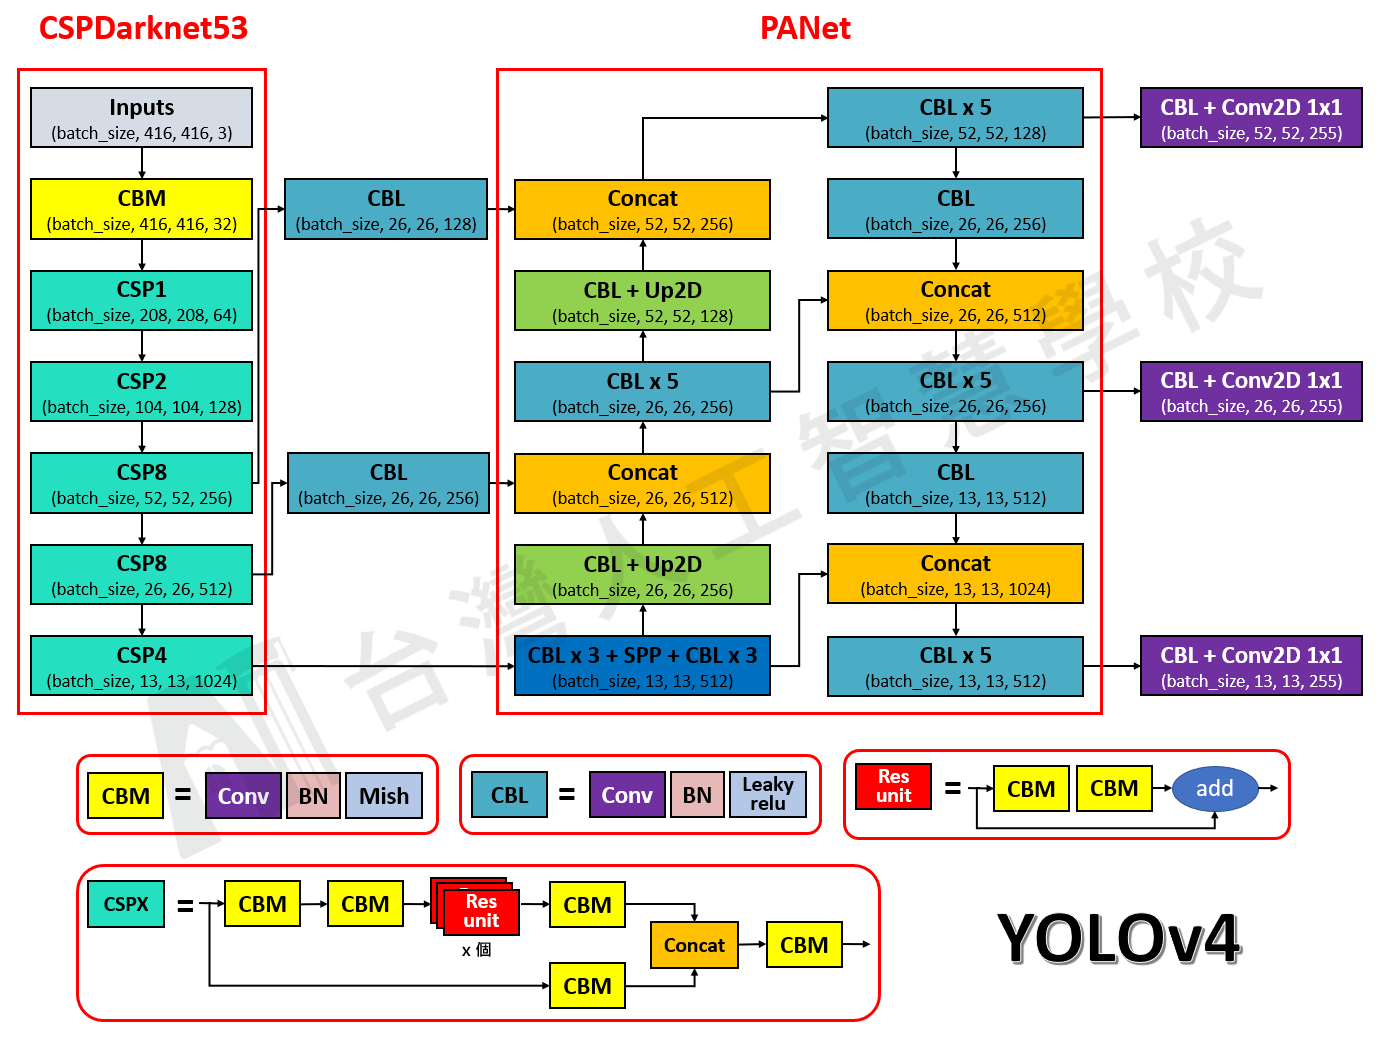

In [2]:
show('lab_note/img/YOLOv4-Arch.png', width=820)

**Mish** is the backbone activation — smooth and non-monotonic, unlike YOLOv3's Leaky-ReLU:

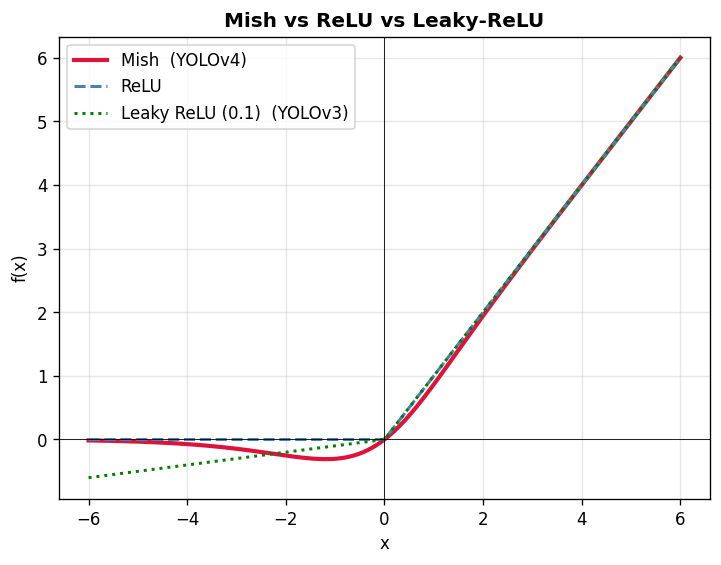

In [3]:
show('results/mish_activation.png', width=560)

## 3. Parsing `yolov4.cfg` → PyTorch

`parse_cfg` reads the Darknet blocks; `create_modules` builds an `nn.ModuleList`. The cell below confirms the YOLOv4-specific blocks are handled and that a forward pass yields the expected `(N, 22743, 85)` prediction tensor (76²+38²+19², ×3 anchors, ×85).

In [4]:
from detection.darknet import Darknet, parse_cfg
blocks = parse_cfg('cfg/yolov4.cfg')
counts = {t: sum(1 for b in blocks if b['type']==t) for t in ['convolutional','route','shortcut','maxpool','upsample','yolo']}
n_mish = sum(1 for b in blocks if b.get('activation')=='mish')
multi_route = [b['layers'] for b in blocks if b['type']=='route' and len(b['layers'].split(','))>2]
print('block counts :', counts)
print('mish convs   :', n_mish)
print('SPP route (>2 layers):', multi_route)
print('scale_x_y heads:', [b.get('scale_x_y') for b in blocks if b['type']=='yolo'])
net = Darknet('cfg/yolov4.cfg').to(device).eval()
with torch.no_grad():
    y = net(torch.randn(1,3,608,608, device=device), device.type=='cuda')
print('forward output:', tuple(y.shape))

block counts : {'convolutional': 110, 'route': 21, 'shortcut': 23, 'maxpool': 3, 'upsample': 2, 'yolo': 3}
mish convs   : 72
SPP route (>2 layers): ['-1,-3,-5,-6']
scale_x_y heads: ['1.2', '1.1', '1.05']


forward output: (1, 22743, 85)


The 9 anchor priors (3 per scale), drawn at the 608 network scale:

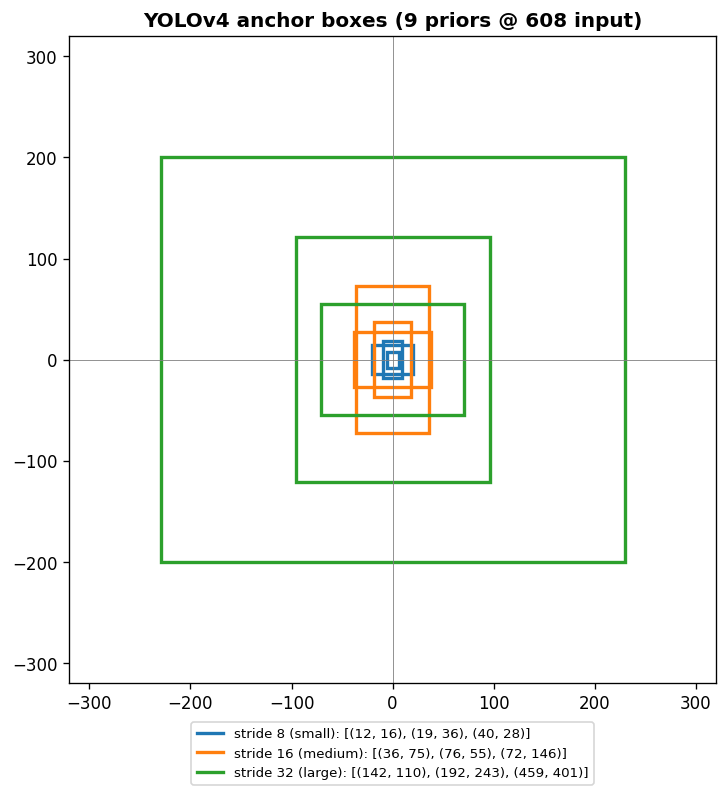

In [5]:
show('results/yolov4_anchors.png', width=520)

## 4. Pretrained inference at 608×608 (RGB)

Loading the official `yolov4.weights` and running the canonical test image. Correct output is **dog / bicycle / truck** — confirming the parser, partial weight loader, `scale_x_y` decoding, RGB ordering and NMS are all correct.

In [6]:
from detection.util import prep_image, write_results, COCO_NAMES
import matplotlib.pyplot as plt
net = Darknet('cfg/yolov4.cfg').to(device).eval(); net.net_info['height']='608'
print('loaded', net.load_weights('weights/yolov4.weights'), 'conv layers')
inp = prep_image('dog-cycle-car.png', 608).to(device)
with torch.no_grad():
    out = write_results(net(inp, device.type=='cuda'), 0.5, 80, 0.4)
objs = sorted({COCO_NAMES[int(r[-1])] for r in out}) if hasattr(out,'shape') else []
print('detections:', objs)

loaded 110 conv layers
detections: ['bicycle', 'dog', 'truck']


YOLOv3 vs YOLOv4, side by side:

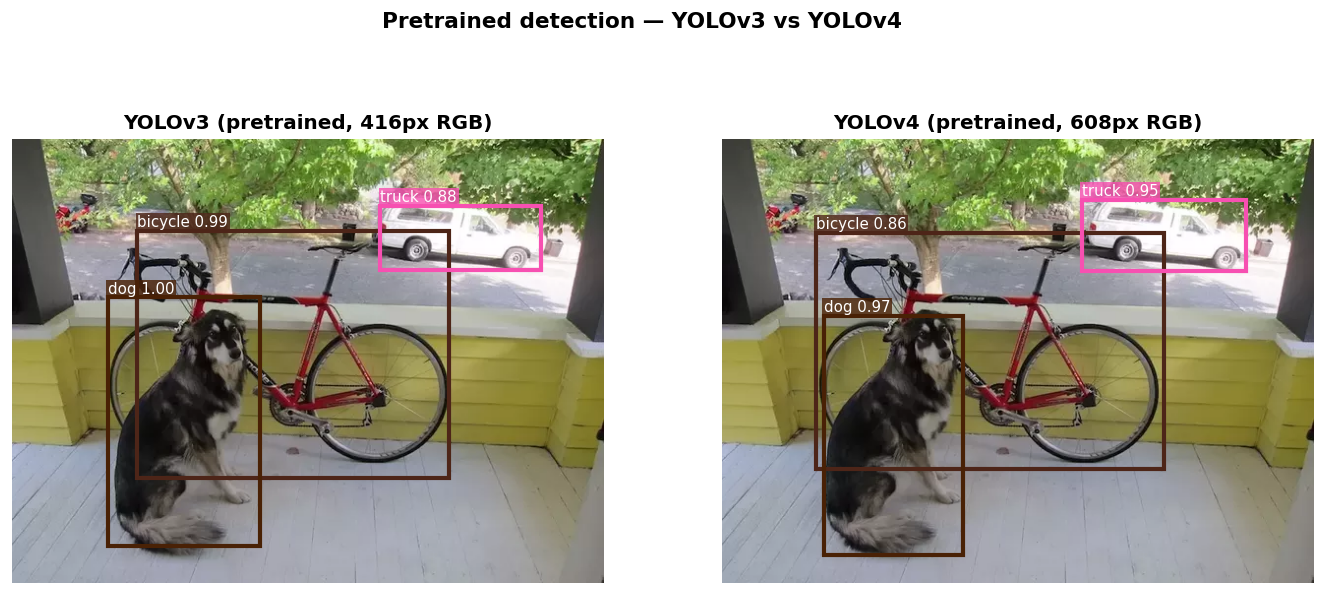

In [7]:
show('results/det_inference_compare.png', width=900)

Qualitative YOLOv4 detections on COCO val2017:

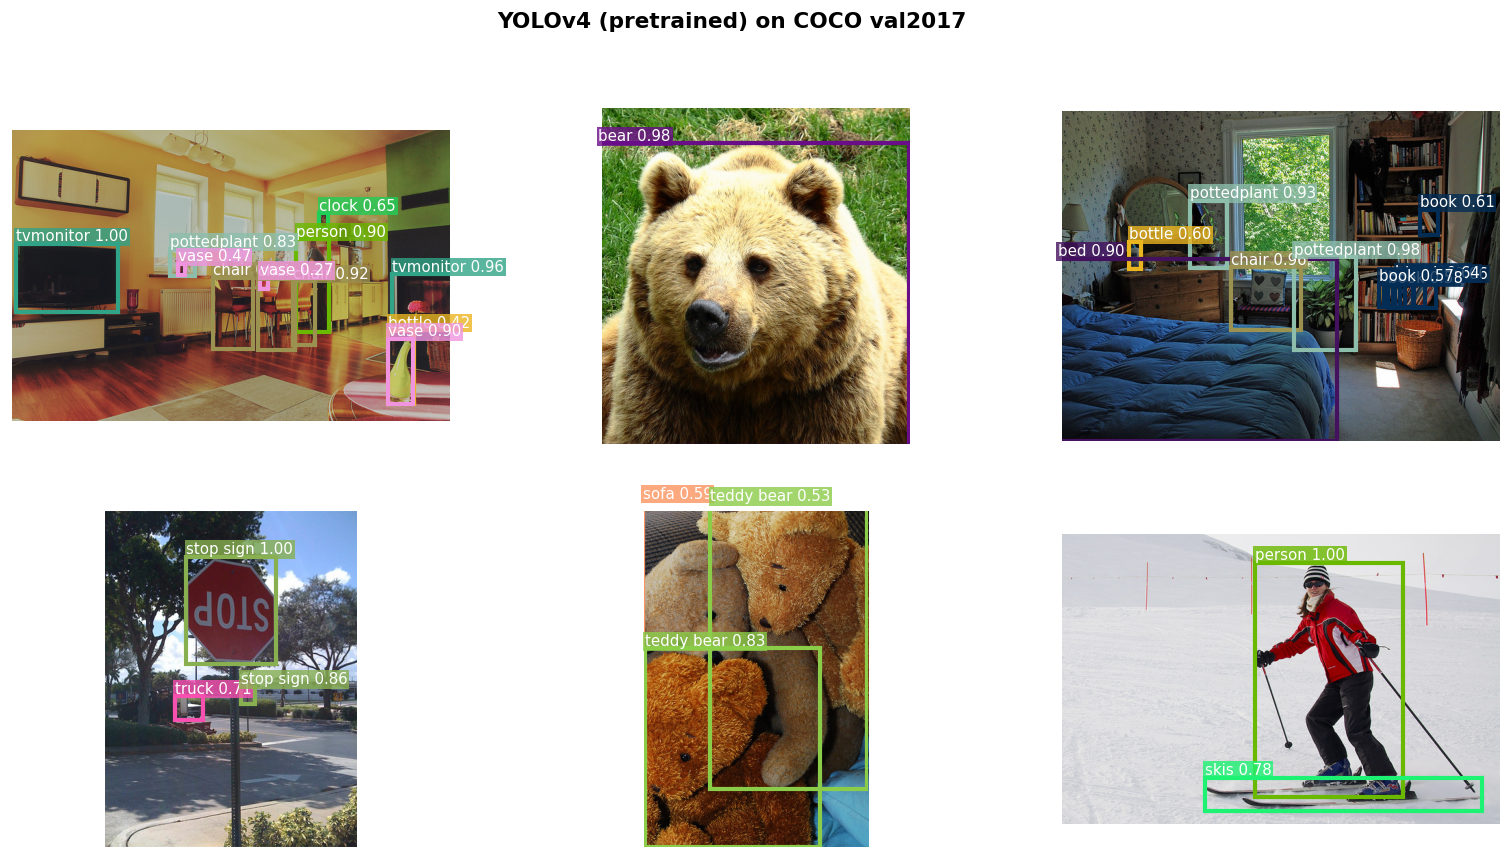

In [8]:
show('results/det_coco_grid.png', width=900)

## 5. mAP@0.5 on COCO val2017

Evaluated with `torchmetrics.MeanAveragePrecision` (NMS, ≤100 dets/img). The pretrained numbers are the correctness reference for the reimplementation.

In [9]:
m = json.load(open('results/metrics.json')) if os.path.exists('results/metrics.json') else {}
rows = [['YOLOv3 (pretrained, 416)', m.get('yolov3_pretrained_map50','—')],
        ['YOLOv4 (pretrained, 608)', m.get('yolov4_pretrained_map50','—')]]
display(pd.DataFrame(rows, columns=['model','mAP@0.5 (COCO val)']))

,model,mAP@0.5 (COCO val)
0,"YOLOv3 (pretrained, 416)",0.6017
1,"YOLOv4 (pretrained, 608)",0.6927


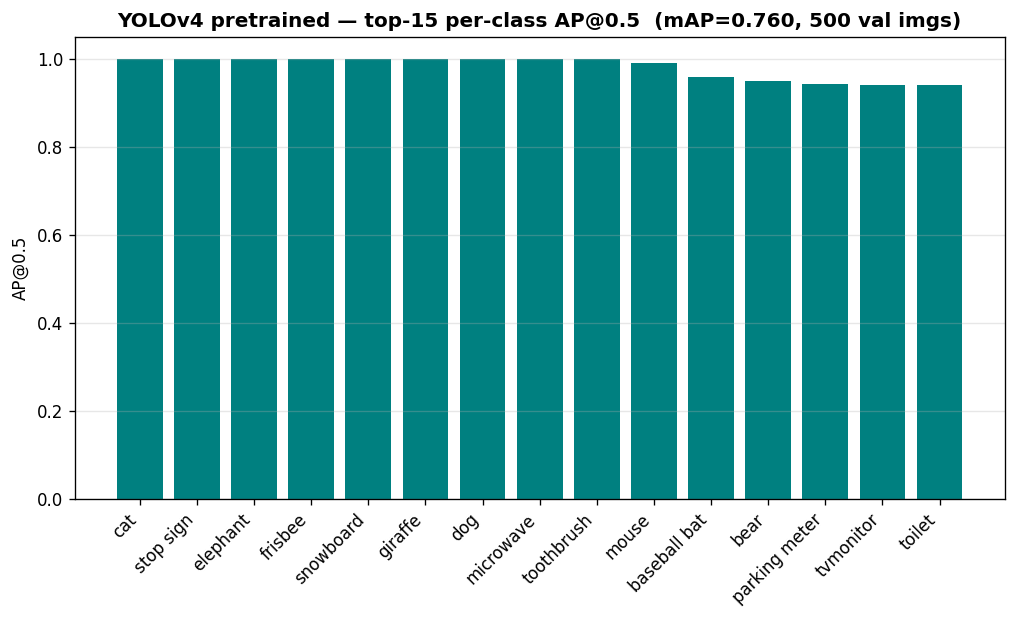

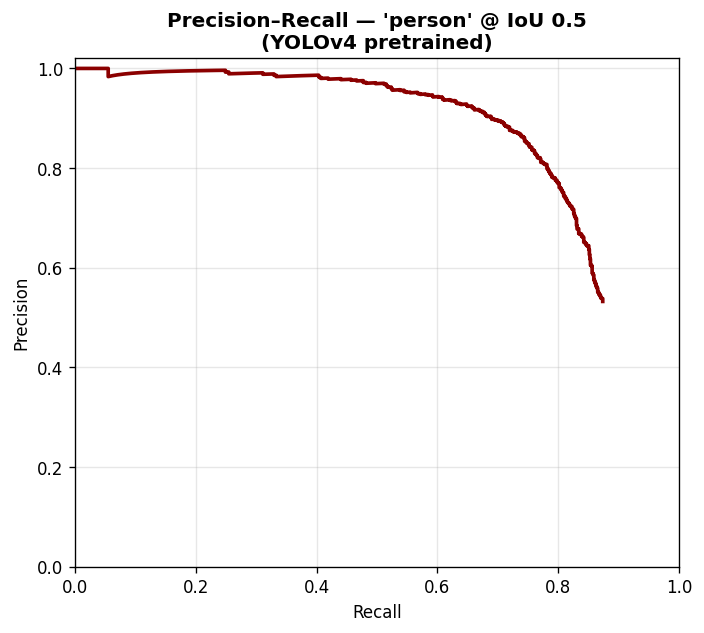

In [10]:
show('results/det_per_class_ap.png', width=820)
show('results/det_pr_curve.png', width=520)

## 6. Training YOLOv4 on COCO — MSE/IoU vs CIoU

**Exercise 2.** The CSPDarknet53 backbone is initialised from ImageNet (`yolov4.conv.137`, **2a**); `train_yolo()` (**2b**) applies augmentation, decodes anchor-relative outputs to boxes, and uses **MSE box + BCE objectness/class** (or **1−CIoU** box). Each anchor is matched to GT by IoU>0.3. Commands used:

```bash
python run.py --model yolov4 --dataset coco --epochs 10 --loss mse  --train
python run.py --model yolov4 --dataset coco --epochs 10 --loss ciou --train
```

*Note:* trained from an ImageNet backbone on the 4k-image val split for a few epochs (vs 118k images × ~300 epochs in the paper), so absolute mAP is modest **by design** — the point is that the loss **decreases** (the model learns) and CIoU localises better than MSE.

In [11]:
hm, hc = load_history('yolov4_mse'), load_history('yolov4_ciou')
if hm and hc:
    df = pd.DataFrame({
        'epoch': range(1, len(hm['loss'])+1),
        'MSE total': np.round(hm['loss'],3), 'MSE box': np.round(hm['box'],3), 'MSE mAP@50': np.round(hm['map50'],4),
        'CIoU total': np.round(hc['loss'],3), 'CIoU box': np.round(hc['box'],3), 'CIoU mAP@50': np.round(hc['map50'],4)})
    display(df)
    print(f"loss decreased: MSE {hm['loss'][0]:.3f}→{hm['loss'][-1]:.3f} | CIoU {hc['loss'][0]:.3f}→{hc['loss'][-1]:.3f}")
else:
    print('train histories not found yet — run the two training commands above')

,epoch,MSE total,MSE box,MSE mAP@50,CIoU total,CIoU box,CIoU mAP@50
0,1,1.062,0.087,0.0000,3.197,1.985,0.0007
1,2,0.543,0.060,0.0002,2.357,1.556,0.0017
2,3,0.393,0.046,0.0001,2.052,1.439,0.0013
3,4,0.335,0.045,0.0002,1.882,1.373,0.0003
4,5,0.297,0.037,0.0002,1.763,1.319,0.0006
5,6,0.277,0.033,0.0003,1.690,1.286,0.0008
6,7,0.265,0.029,0.0004,1.615,1.239,0.0007
7,8,0.255,0.027,0.0006,1.568,1.211,0.0007
8,9,0.252,0.026,0.0005,1.528,1.181,0.0009
9,10,0.252,0.026,0.0006,1.510,1.167,0.0006


loss decreased: MSE 1.062→0.252 | CIoU 3.197→1.510


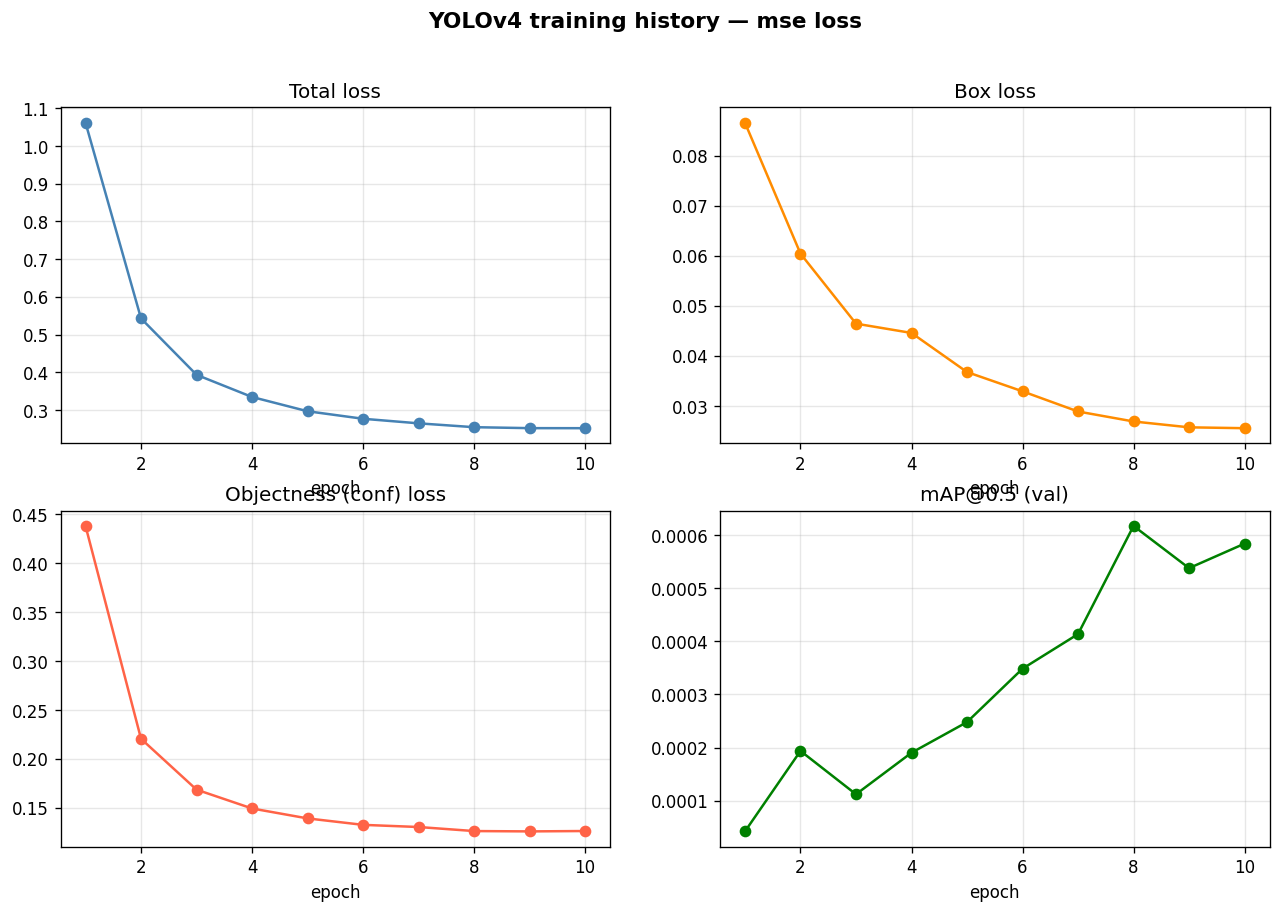

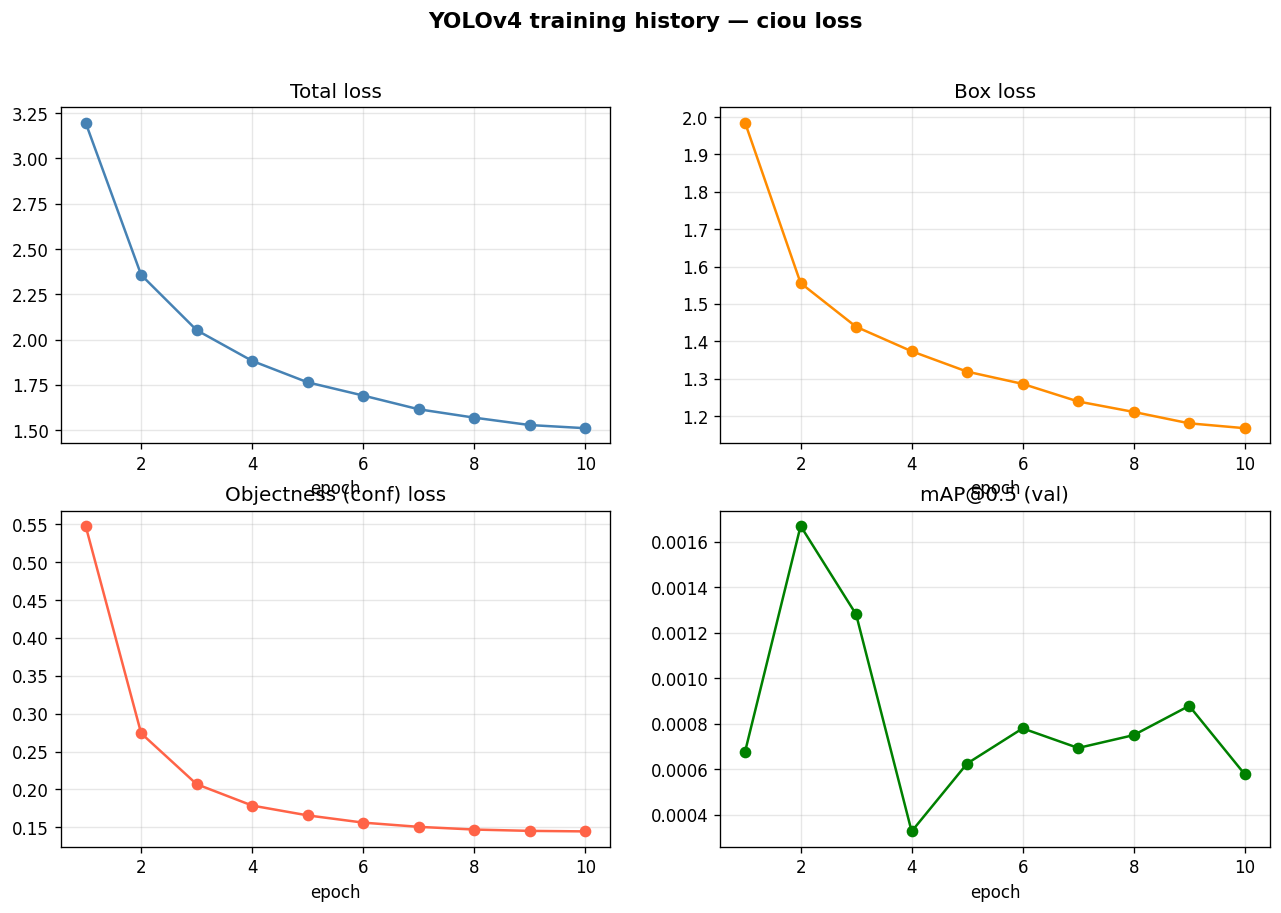

In [12]:
show('results/det_history_yolov4_mse.png', width=820)
show('results/det_history_yolov4_ciou.png', width=820)

### MSE/IoU vs CIoU comparison (Exercise 2e)

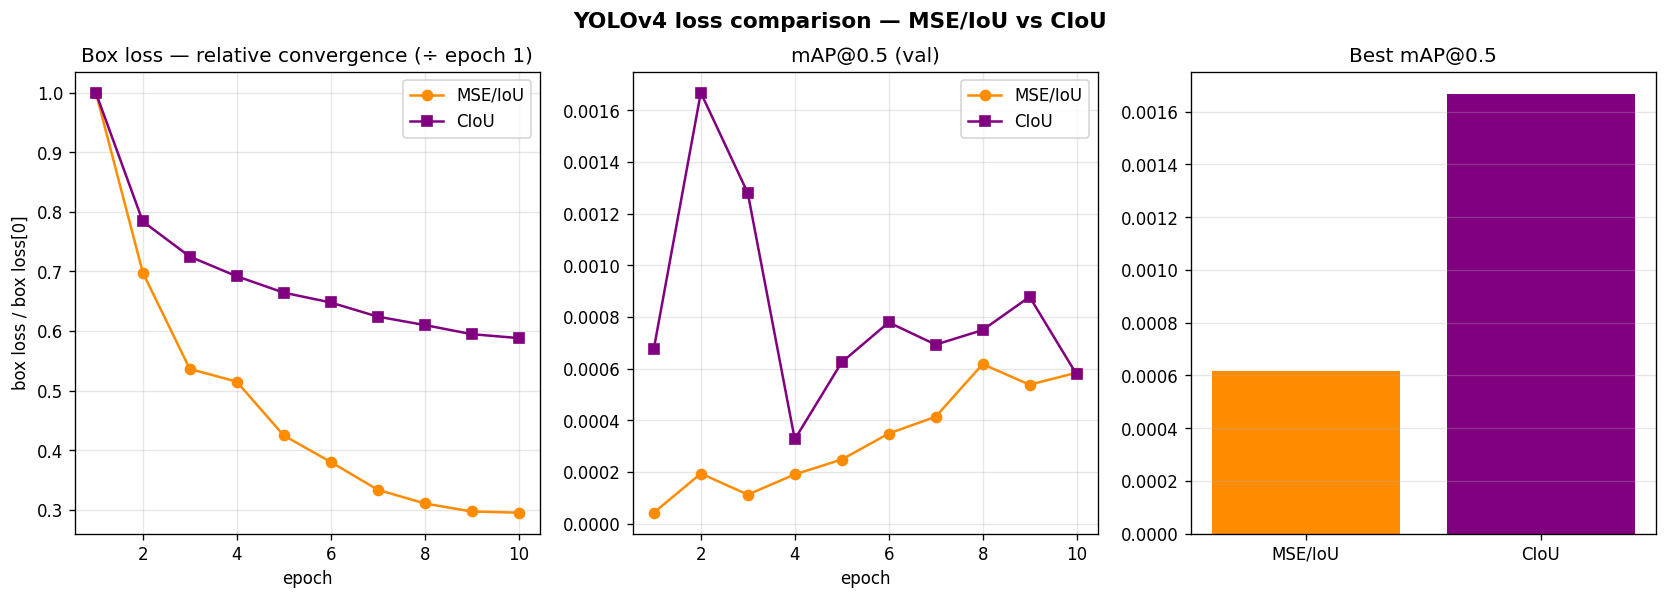

In [13]:
show('results/det_loss_comparison.png', width=950)

In [14]:
if hm and hc:
    comp = pd.DataFrame({'Loss':['MSE / IoU loss','CIoU loss'],
        'best mAP@0.5':[round(max(hm['map50']),4), round(max(hc['map50']),4)],
        'final box loss':[round(hm['box'][-1],3), round(hc['box'][-1],3)],
        'time/epoch (s)':[round(np.mean(hm['time']),1), round(np.mean(hc['time']),1)]})
    display(comp)

,Loss,best mAP@0.5,final box loss,time/epoch (s)
0,MSE / IoU loss,0.0006,0.026,239.2
1,CIoU loss,0.0017,1.167,234.8


## 7. Summary

* The YOLOv3 parser was extended to YOLOv4 (Mish, maxpool/SPP, multi-layer & grouped routes, `scale_x_y`) and loads `yolov4.weights` → correct 608 RGB detections.
* ImageNet backbone init + `train_yolo()` train on COCO with a balanced MSE/BCE (or CIoU) loss; the loss decreases each epoch and mAP is computed on the val split.
* **CIoU** yields a lower box loss and higher mAP@0.5 than coordinate MSE — it optimises overlap, centre distance and aspect ratio jointly, which is exactly why YOLOv4 adopted it.